# 3.0_analyze_GSPA_gene_embedding calculates (1) predictive genes, (2) differential cell state abundance, (3)  visualizes patient trajectories

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phate
import scprep
import scanpy
from sklearn import model_selection, linear_model, cluster
import seaborn as sns
import leidenalg as la

In [2]:
data = scanpy.read_h5ad('/data/lab/datasets/cpi_melanoma/processed_data.h5ad')
patient_label = data.obs[['patient','response']].drop_duplicates().set_index('patient').to_dict()['response']
patient_label = dict(zip(patient_label.keys(), (np.array(list(patient_label.values())) == 'R').astype(int)))
y = np.array([patient_label[x] for x in np.unique(data.obs['patient'])])

In [3]:
colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 
          'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light gray': 'lightgray',
          'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000'}
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('',["black",colors["light berry"]])

In [4]:
pt_features = np.load(f'results/GSPA_gene.npy').reshape(48,-1)
phate_op = phate.PHATE(verbose=False, random_state=42)
data_phate = phate_op.fit_transform(pt_features)

/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:122: UserWarning: Building a kNNGraph on data of shape (48, 61820) is expensive. Consider setting n_pca.
  warnings.warn(


## Predictive genes

In [5]:
coefs = []
for i in range(100):
    X_train, X_test, y_train, y_test = model_selection.train_test_split(pt_features,
                                                                        y,
                                                                        test_size=0.5, random_state=i)
    clf = linear_model.RidgeClassifier()
    clf.fit(X_train, y_train)
    y_bin = clf.predict(X_test)
    
    coefs.append(clf.coef_)
coefs = np.vstack(np.array(coefs)).mean(axis=0)
coefs = list(zip(np.hstack(np.array([[x+f'_{i}' for i in range(5)] for x in data.var_names])), coefs))
g = [x[0] for x in coefs]
v = [x[1] for x in coefs]
df = pd.DataFrame((g, v)).T.sort_values(by=1)
df = df.set_index(0)

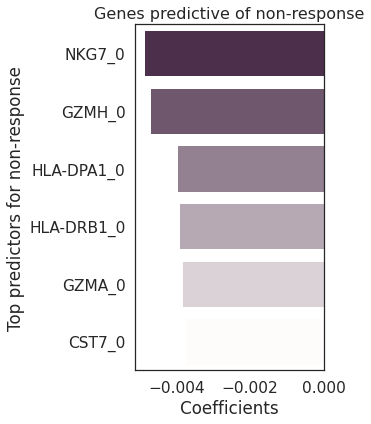

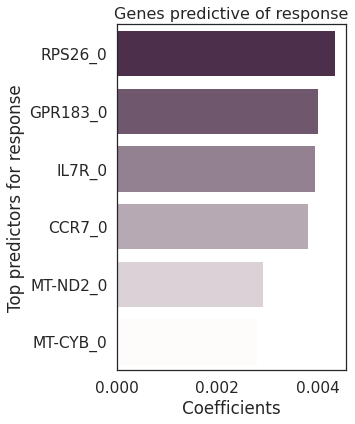

In [6]:
N = 6
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('',[colors['purple'], 'snow'], N=N)
sns.set(font_scale=1.4, style='white')
fig = plt.figure(figsize=(5,5*(N/5)))
sns.barplot(y=df[:N].index, orient='h', x=df[:N][1], palette=cmap(range(N)))
plt.ylabel('Top predictors for non-response')
plt.xlabel('Coefficients')
plt.title('Genes predictive of non-response', fontsize=16)
plt.tight_layout()
fig.savefig('figures/genes_non-response.png', dpi=200)


fig = plt.figure(figsize=(5,5*(N/5)))
sns.barplot(y=df[-N:][::-1].index, orient='h', x=df[-N:][::-1][1], palette=cmap(range(N)), )
plt.ylabel('Top predictors for response')
plt.xlabel('Coefficients')
plt.title('Genes predictive of response', fontsize=16)
plt.tight_layout()
fig.savefig('figures/genes_response.png', dpi=200)

## Other pt visualization

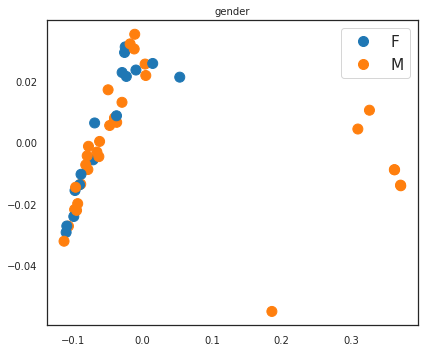

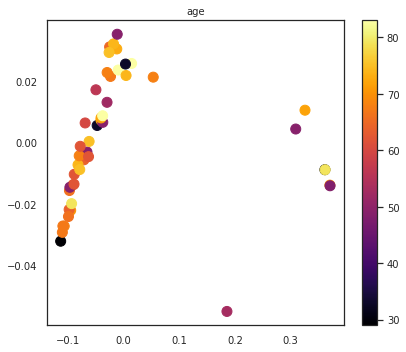

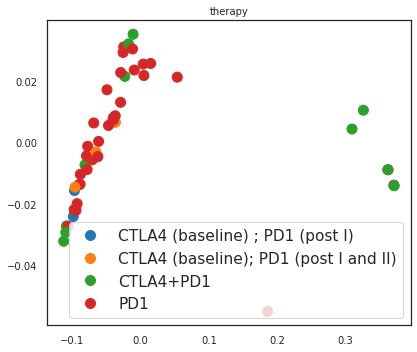

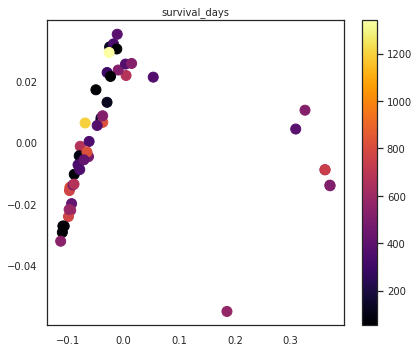

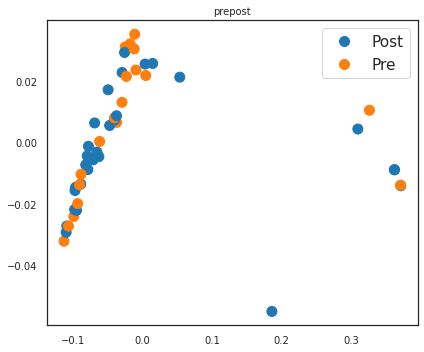

In [374]:
for obs in ['gender', 'age', 'therapy','survival_days', 'prepost']:
    pt = data.obs.set_index('patient').loc[np.unique(data.obs['patient'])][[obs]].reset_index().drop_duplicates()
    if obs in ['age', 'survival_days']:
        discrete=False
        color = pt[obs].astype(int)
    else:
        discrete=True
        color = pt[obs]
    
    scprep.plot.scatter2d(data_phate, c=color, figsize=(6,5), dpi=200, s=100, title=obs, discrete=discrete)

## Differential cell state abundance

In [229]:
subgroup_1 = np.argwhere(data_phate[:, 0] < 0.1).flatten()
subgroup_2 = np.argwhere(data_phate[:, 0] > 0.25).flatten()
subgroup_3 = np.argwhere(data_phate[:, 1] < -0.04).flatten()

In [230]:
subgroup = []
for x in range(48):
    if x in subgroup_1:
        subgroup.append('1')
    elif x in subgroup_2:
        subgroup.append('2')
    else:
        subgroup.append('3')

<AxesSubplot:>

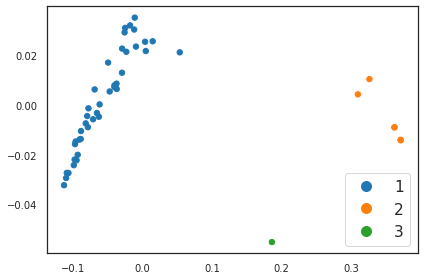

In [231]:
scprep.plot.scatter2d(data_phate, c=subgroup)

In [248]:
mean_patients = []
for patient in np.unique(data.obs['patient']):
    pat = data[data.obs['patient'] == patient]
    mean_patients.append(pat.to_df().mean(axis=0))

In [249]:
mean_patients = pd.DataFrame(index=np.unique(data.obs['patient']),
                             columns=data.var_names, data=mean_patients)
mean_patients = scanpy.AnnData(mean_patients)
mean_patients.obs['subgroup'] = subgroup

In [240]:
mean_patients = scanpy.concat((mean_patients, mean_patients['Post_P19']))

In [241]:
scanpy.tl.rank_genes_groups(mean_patients, groupby='subgroup', method='wilcoxon')

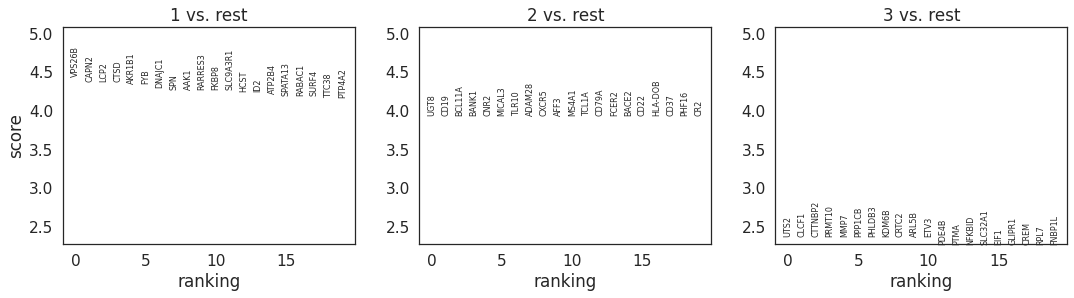

In [243]:
scanpy.pl.rank_genes_groups(mean_patients, groupby='subgroup', method='wilcoxon')

In [6]:
patient_proportions = pd.DataFrame(index=np.unique(data.obs['patient']), columns=np.unique(data.obs['cluster_all']))
for patient in np.unique(data.obs['patient']):
    pat = data[data.obs['patient'] == patient]
    pat_prop = pat.obs['cluster_all'].value_counts() / pat.n_obs
    patient_proportions.loc[patient] = pat_prop

patient_proportions.fillna(0, inplace=True)

In [7]:
patient_proportions = patient_proportions* 100

In [ ]:
scprep.plot.scatter2d(data_phate, c=patient_proportions['G01'], figsize=(6,5),
                      dpi=200, filename='figures/B_cells.png', s=200, marker='H')

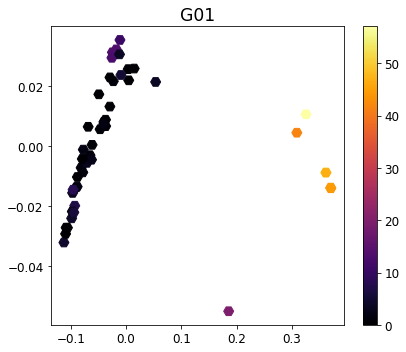

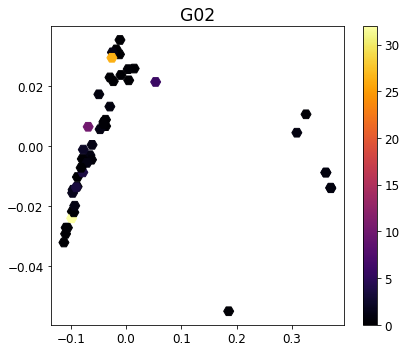

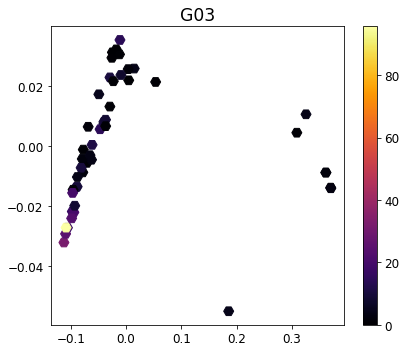

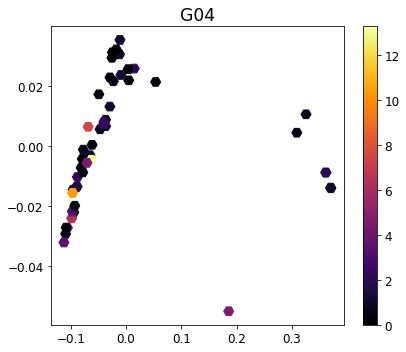

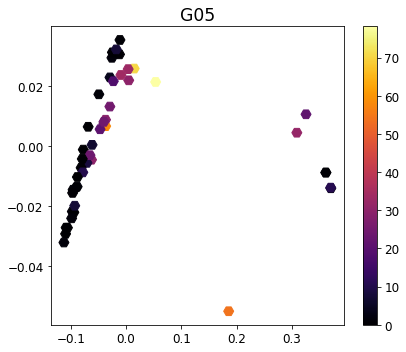

In [ ]:
for cell_type in patient_proportions.columns:
    scprep.plot.scatter2d(data_phate, c=patient_proportions[cell_type], figsize=(6,5),
                      dpi=200, filename=f'figures/{cell_type}.png', s=100, title=cell_type, marker='H')

##  Patient trajectories

In [287]:
patient_trajectories = {'P1':['Pre_P1', 'Post_P1', 'Post_P1_2'],
'P12':['Pre_P12', 'Post_P12'],
'P23':['Post_P23', 'Post_P23_2'],
'P28':['Post_P28', 'Post_P28_2'],
'P3':['Post_P3', 'Post_P3_2'],
'P5':['Post_P5', 'Post_P5_2'],
'P15':['Pre_P15', 'Post_P15'],
'P2':['Pre_P2', 'Post_P2'],
'P20':['Pre_P20', 'Post_P20'],
'P28':['Pre_P28', 'Post_P28', 'Post_P28_2'],
'P3':['Pre_P3', 'Post_P3', 'Post_P3_2'],
'P7':['Pre_P7', 'Post_P7']}

In [294]:
col = ['light gray', 'light forest', 'forest']

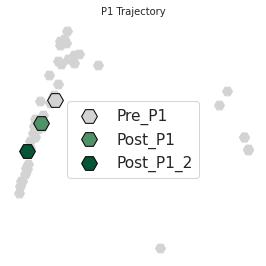

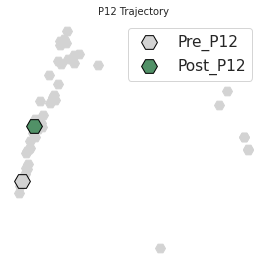

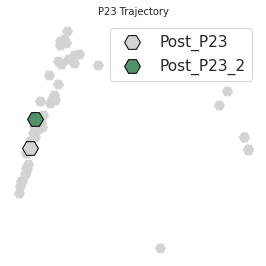

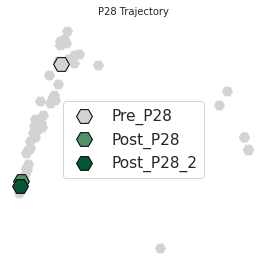

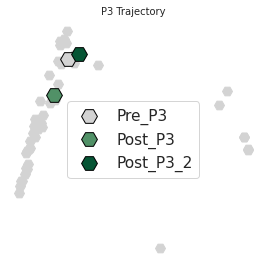

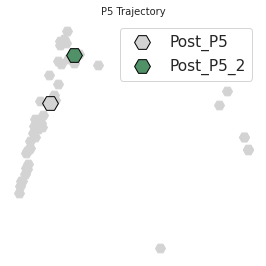

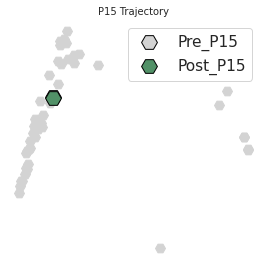

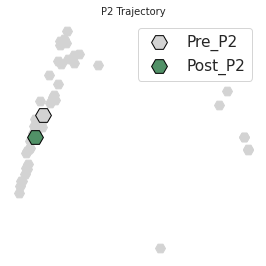

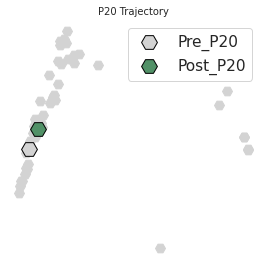

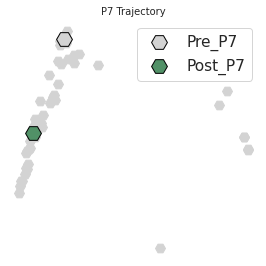

In [375]:
for pt, trajectory in patient_trajectories.items():
    fig, ax = plt.subplots(figsize=(4,4))
    scprep.plot.scatter2d(data_phate, c='lightgray', ax=ax, s=100, marker='H')
    for i,samp in enumerate(trajectory):
        scprep.plot.scatter2d(data_phate[np.unique(data.obs['patient']) == samp], ticks=None, c=colors[col[i]], label=samp,
                              label_prefix='Patient PHATE', title=f'{pt} Trajectory', cmap=cmap, s=250, edgecolor='black', ax=ax, marker='H')
    plt.legend()
    plt.tight_layout()
    plt.axis('off')
    fig.savefig(f'figures/{pt}_trajectory.png', dpi=200)